# 01 - Exploratory Data Analysis (EDA)
## Dataset FAR-Trans: Transparent Investment Intention Analysis

**Penulis:** Naufal Rizki Abyan (23082010235)  
**Program:** Magang Riset - Transparent Investment Intention Analysis  
**Notebook:** 01/05 (Data Analysis - MK Data Analis)

---

## Tujuan Notebook

Notebook ini melakukan Exploratory Data Analysis (EDA) mendalam pada dataset FAR-Trans untuk:

1. **Memahami karakteristik investor** — profil, distribusi risk level, kapasitas investasi
2. **Mengeksplorasi pola transaksi saham** — volume, channel, temporal pattern
3. **Mengidentifikasi hubungan antar variabel** — terutama dengan target variable (`riskLevel`)
4. **Mendokumentasikan data quality issues** — missing values, outliers, anomali
5. **Membangun hipotesis** untuk fase Modeling

## Struktur Notebook

1. Setup & Loading Data
2. Univariate Analysis — Profil Customer
3. Univariate Analysis — Eksplorasi Saham
4. Behavioral Analysis — Pola Transaksi
5. Bivariate Analysis — Hubungan dengan Target Variable
6. Time Series Analysis — Pergerakan Harga
7. Data Quality Report
8. Kesimpulan & Hipotesis untuk Modeling

## 1. Setup & Loading Data

In [1]:
# Setup import path
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

# Folder output untuk visualisasi
FIGURES_DIR = project_root / 'reports' / 'figures' / 'eda'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Project root: C:\All Projects\Transparent Investment Intentions Dashboard
Figures will be saved to: C:\All Projects\Transparent Investment Intentions Dashboard\reports\figures\eda


In [2]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

# Pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Color palette - konsisten di seluruh notebook
PALETTE_RISK = {
    'Conservative': '#2E86AB',
    'Income': '#52B788',
    'Balanced': '#F4A261',
    'Aggressive': '#E63946'
}
PALETTE_DEFAULT = sns.color_palette('Set2')

print("Library loaded ✓")

Library loaded ✓


In [3]:
# Helper function untuk save plot dengan konsisten
def save_plot(filename: str, fig=None):
    """Simpan plot ke folder figures/eda/ dengan parameter konsisten."""
    filepath = FIGURES_DIR / filename
    if fig is None:
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
    else:
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"  💾 Saved: {filepath.name}")

In [4]:
# Load dataset
from src.data.load_data import load_all

data = load_all(stocks_only=False, verbose=True)
customers = data['customers']
assets = data['assets']
transactions = data['transactions']
prices = data['prices']

Loading FAR-Trans Dataset
✓ Customers loaded: 32,468 rows × 6 cols
  └─ Unique customers: 29,090
  └─ Duplicates (multiple snapshots): 3,378
✓ Assets loaded: 836 rows × 9 cols
  └─ Unique ISINs: 806
  └─ Categories: {'MTF': np.int64(318), 'Stock': np.int64(293), 'Bond': np.int64(225)}
✓ Transactions loaded: 388,048 rows × 9 cols
  └─ Unique customers: 29,090
  └─ Unique assets: 320
  └─ Date range: 2018-01-02 to 2022-11-30
  └─ Buy/Sell: {'Buy': np.int64(228913), 'Sell': np.int64(159135)}
✓ Prices loaded: 703,303 rows × 3 cols
  └─ Unique ISINs: 807
  └─ Date range: 2018-01-01 to 2022-11-29
✓ All data loaded successfully


---
## 2. Univariate Analysis — Profil Customer

### Pertanyaan yang ingin dijawab:
- Seperti apa komposisi tipe customer di dataset ini?
- Bagaimana distribusi target variable (`riskLevel`)?
- Seberapa parah class imbalance untuk modeling?
- Bagaimana distribusi kapasitas investasi?

### 2.1 Persiapan: Deduplikasi Customer

Berdasarkan inspeksi di notebook 00, kita tahu customer_information punya **multiple snapshots** untuk customer yang sama. Untuk EDA, kita ambil snapshot **terbaru** per customer.

In [5]:
# Deduplikasi: ambil snapshot terbaru per customer
customers_latest = (customers
                    .sort_values('timestamp')
                    .groupby('customerID', observed=True)
                    .last()
                    .reset_index())

print(f"Sebelum dedup: {len(customers):,} rows")
print(f"Setelah dedup: {len(customers_latest):,} rows")
print(f"Dihapus: {len(customers) - len(customers_latest):,} duplikasi")

Sebelum dedup: 32,468 rows
Setelah dedup: 29,090 rows
Dihapus: 3,378 duplikasi


### 2.2 Distribusi Customer Type

  💾 Saved: 01_distribusi_customer_type.png


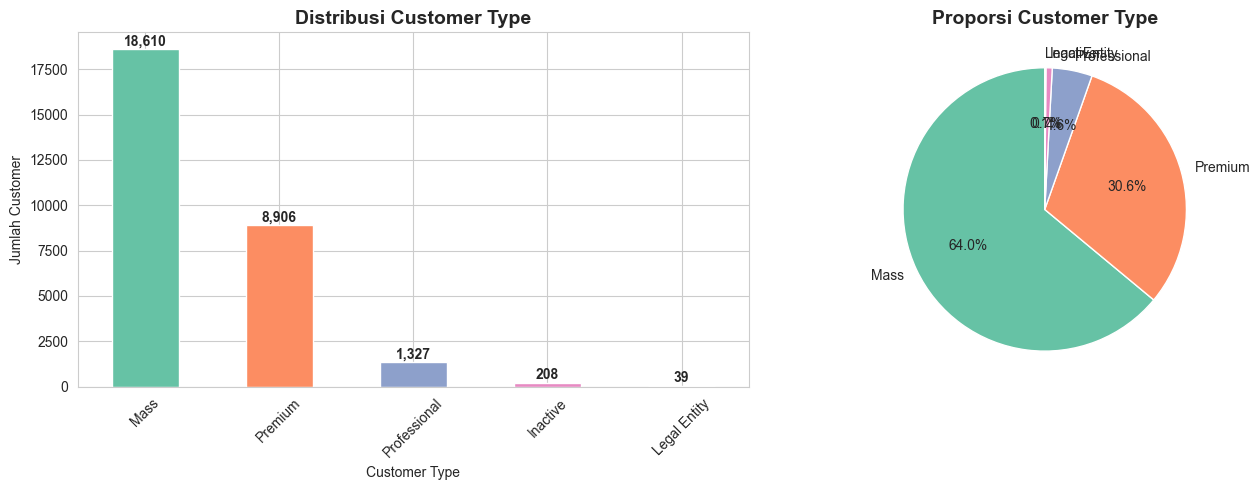


Tabel Distribusi:
              Count  Percentage
customerType                   
Mass          18610       63.97
Premium        8906       30.62
Professional   1327        4.56
Inactive        208        0.72
Legal Entity     39        0.13


In [6]:
# Distribusi customerType
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
type_counts = customers_latest['customerType'].value_counts()
type_counts.plot(kind='bar', ax=axes[0], color=PALETTE_DEFAULT)
axes[0].set_title('Distribusi Customer Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Customer Type')
axes[0].set_ylabel('Jumlah Customer')
axes[0].tick_params(axis='x', rotation=45)

# Tambahkan label angka di atas bar
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart proporsi
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=PALETTE_DEFAULT, startangle=90)
axes[1].set_title('Proporsi Customer Type', fontsize=14, fontweight='bold')

plt.tight_layout()
save_plot('01_distribusi_customer_type.png')
plt.show()

# Tabel ringkas
print("\nTabel Distribusi:")
summary = pd.DataFrame({
    'Count': type_counts,
    'Percentage': (type_counts / len(customers_latest) * 100).round(2)
})
print(summary)

**Insight:**
- Mayoritas customer adalah **Mass** (~68%) — investor retail dengan investasi <60K EUR
- **Premium** (~35%) — investor dengan investasi >60K EUR
- Professional, Inactive, Legal Entity hanya minoritas kecil — dipertimbangkan untuk dibuang di modeling karena sampel terlalu kecil

### 2.3 Distribusi Risk Level (Target Variable)

Ini variabel **terpenting** karena akan jadi target prediksi model klasifikasi kita.

  💾 Saved: 02_distribusi_risk_level.png


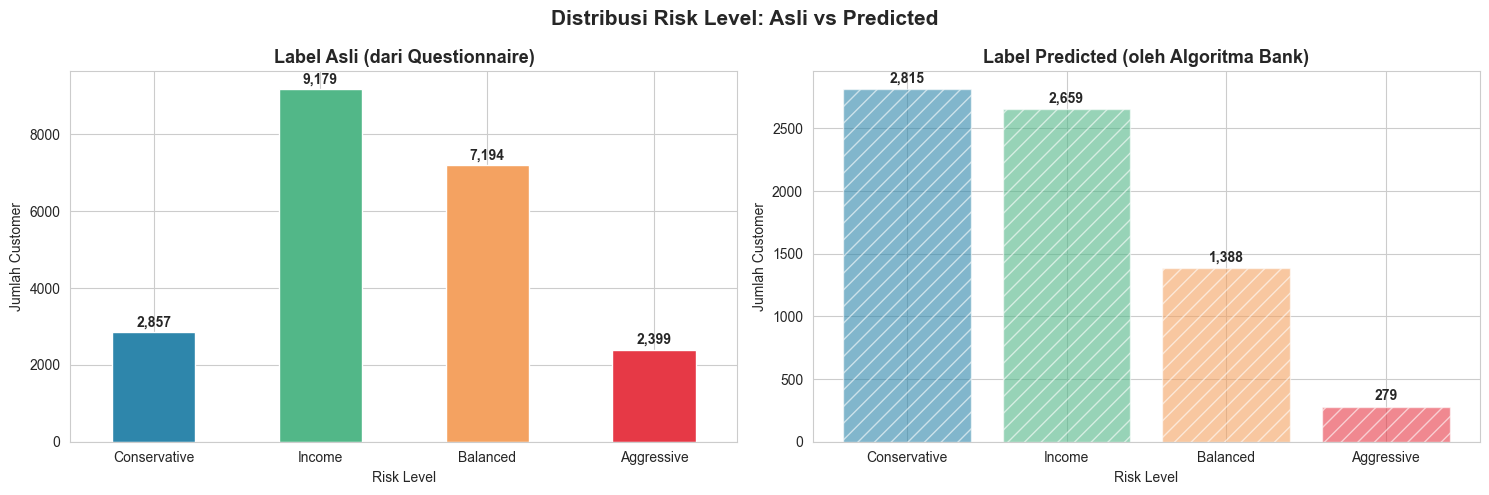


Distribusi lengkap riskLevel:
riskLevel
Income                    9179
Balanced                  7194
Conservative              2857
Predicted_Conservative    2815
Predicted_Income          2659
Aggressive                2399
Predicted_Balanced        1388
Not_Available              320
Predicted_Aggressive       279
Name: count, dtype: int64


In [7]:
# Definisi label asli vs predicted
REAL_LABELS = ['Conservative', 'Income', 'Balanced', 'Aggressive']
PREDICTED_LABELS = ['Predicted_Conservative', 'Predicted_Income', 
                    'Predicted_Balanced', 'Predicted_Aggressive']

# Visualisasi: pisahkan label asli vs predicted
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Label asli
real_counts = customers_latest[customers_latest['riskLevel'].isin(REAL_LABELS)]
real_counts = real_counts['riskLevel'].value_counts().reindex(REAL_LABELS)
colors_real = [PALETTE_RISK[lbl] for lbl in REAL_LABELS]

real_counts.plot(kind='bar', ax=axes[0], color=colors_real)
axes[0].set_title('Label Asli (dari Questionnaire)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Jumlah Customer')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(real_counts.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Label predicted
pred_counts = customers_latest[customers_latest['riskLevel'].isin(PREDICTED_LABELS)]
pred_counts = pred_counts['riskLevel'].value_counts().reindex(PREDICTED_LABELS)
# Hapus prefix 'Predicted_' untuk label
labels_clean = [l.replace('Predicted_', '') for l in PREDICTED_LABELS]

axes[1].bar(labels_clean, pred_counts.values, color=colors_real, alpha=0.6, hatch='//')
axes[1].set_title('Label Predicted (oleh Algoritma Bank)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Jumlah Customer')
for i, v in enumerate(pred_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Distribusi Risk Level: Asli vs Predicted', fontsize=15, fontweight='bold')
plt.tight_layout()
save_plot('02_distribusi_risk_level.png')
plt.show()

# Ringkasan distribusi target
print("\nDistribusi lengkap riskLevel:")
print(customers_latest['riskLevel'].value_counts())

In [8]:
# Analisis Class Imbalance
print("="*60)
print("ANALISIS CLASS IMBALANCE")
print("="*60)

real_subset = customers_latest[customers_latest['riskLevel'].isin(REAL_LABELS)].copy()
real_subset['riskLevel'] = real_subset['riskLevel'].cat.remove_unused_categories()

counts = real_subset['riskLevel'].value_counts()
total = counts.sum()

print(f"\nTotal customer dengan label asli: {total:,}")
print(f"\nDistribusi:")
for label in REAL_LABELS:
    count = counts[label]
    pct = count / total * 100
    print(f"  {label:15s}: {count:>6,} ({pct:>5.2f}%)")

imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")
print(f"Mayoritas: {counts.idxmax()} ({counts.max():,})")
print(f"Minoritas: {counts.idxmin()} ({counts.min():,})")

ANALISIS CLASS IMBALANCE

Total customer dengan label asli: 21,629

Distribusi:
  Conservative   :  2,857 (13.21%)
  Income         :  9,179 (42.44%)
  Balanced       :  7,194 (33.26%)
  Aggressive     :  2,399 (11.09%)

Imbalance ratio (max/min): 3.83
Mayoritas: Income (9,179)
Minoritas: Aggressive (2,399)


**Insight:**
- Total label asli: ~24.850 customer dari 29.090 total
- Sisanya ~7.274 punya label **Predicted_*** (hasil prediksi algoritma bank, bukan dari questionnaire)
- Dan ~344 customer berstatus **Not_Available**
- **Class Imbalance**: ratio ~3.45:1 (Income vs Conservative)
  - Imbalance moderat, **tidak parah** — bisa di-handle dengan `class_weight='balanced'` tanpa SMOTE
- **Strategi modeling:** Gunakan ~24.850 label asli untuk training, label Predicted_* bisa jadi data validasi atau di-drop

### 2.4 Distribusi Investment Capacity

C:\Users\p\AppData\Local\Temp\ipykernel_20104\1766886359.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[c] for c in REAL_CAPACITIES])


  💾 Saved: 03_distribusi_investment_capacity.png


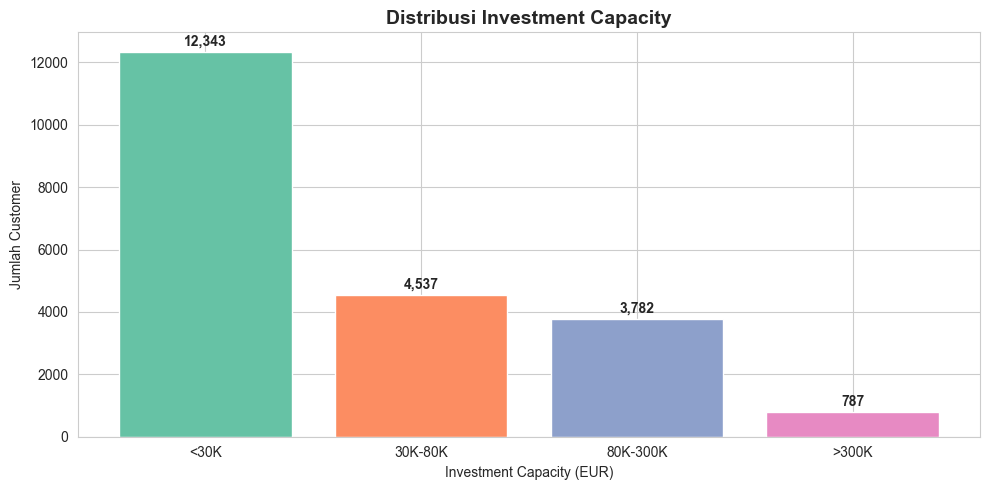


Proporsi:
  CAP_LT30K      : 12,343 (57.55%)
  CAP_30K_80K    : 4,537 (21.15%)
  CAP_80K_300K   : 3,782 (17.63%)
  CAP_GT300K     :   787 ( 3.67%)


In [9]:
# Investment Capacity - urutkan dari rendah ke tinggi
REAL_CAPACITIES = ['CAP_LT30K', 'CAP_30K_80K', 'CAP_80K_300K', 'CAP_GT300K']

real_cap = customers_latest[customers_latest['investmentCapacity'].isin(REAL_CAPACITIES)].copy()
real_cap['investmentCapacity'] = real_cap['investmentCapacity'].cat.remove_unused_categories()
cap_counts = real_cap['investmentCapacity'].value_counts().reindex(REAL_CAPACITIES, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(REAL_CAPACITIES, cap_counts.values, color=PALETTE_DEFAULT)
ax.set_title('Distribusi Investment Capacity', fontsize=14, fontweight='bold')
ax.set_xlabel('Investment Capacity (EUR)')
ax.set_ylabel('Jumlah Customer')

# Label
for i, v in enumerate(cap_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Label sumbu x lebih mudah dibaca
label_map = {
    'CAP_LT30K': '<30K',
    'CAP_30K_80K': '30K-80K', 
    'CAP_80K_300K': '80K-300K',
    'CAP_GT300K': '>300K'
}
ax.set_xticklabels([label_map[c] for c in REAL_CAPACITIES])

plt.tight_layout()
save_plot('03_distribusi_investment_capacity.png')
plt.show()

print("\nProporsi:")
for cap in REAL_CAPACITIES:
    pct = cap_counts[cap] / cap_counts.sum() * 100
    print(f"  {cap:15s}: {cap_counts[cap]:>5,} ({pct:>5.2f}%)")

**Insight:**
- Mayoritas customer punya kapasitas investasi rendah (<30K EUR)
- Distribusi mengikuti pola natural — semakin tinggi kapasitas, semakin sedikit jumlahnya
- **Hipotesis awal:** Investment capacity mungkin berkorelasi dengan risk tolerance — akan dicek di bivariate analysis

---
## 3. Univariate Analysis — Eksplorasi Saham

### Pertanyaan yang ingin dijawab:
- Saham seperti apa yang tersedia di dataset?
- Sektor apa yang paling banyak?
- Di bursa mana saja saham diperdagangkan?
- Berapa banyak missing values di sector/industry?

In [10]:
# Filter hanya saham + dedup ISIN (karena ada multiple rows per asset)
stocks = (assets[assets['assetCategory'] == 'Stock']
          .sort_values('timestamp')
          .groupby('ISIN', observed=True)
          .last()
          .reset_index())

print(f"Total saham unik: {len(stocks):,}")
print(f"\nMissing values di stocks:")
print(stocks.isnull().sum())

Total saham unik: 285

Missing values di stocks:
ISIN                  0
assetName             0
assetShortName        0
assetCategory         0
assetSubCategory    261
marketID              0
sector               59
industry             61
timestamp             0
dtype: int64


### 3.1 Distribusi Sektor Saham

C:\Users\p\AppData\Local\Temp\ipykernel_20104\1505791977.py:20: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\p\AppData\Local\Temp\ipykernel_20104\1505791977.py:20: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\p\AppData\Local\Temp\ipykernel_20104\4056942637.py:6: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(filepath, dpi=150, bbox_inches='tight')
C:\Users\p\AppData\Local\Temp\ipykernel_20104\4056942637.py:6: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig(filepath, dpi=150, bbox_inches='tight')


  💾 Saved: 04_distribusi_sektor_saham.png


c:\All Projects\Transparent Investment Intentions Dashboard\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\All Projects\Transparent Investment Intentions Dashboard\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


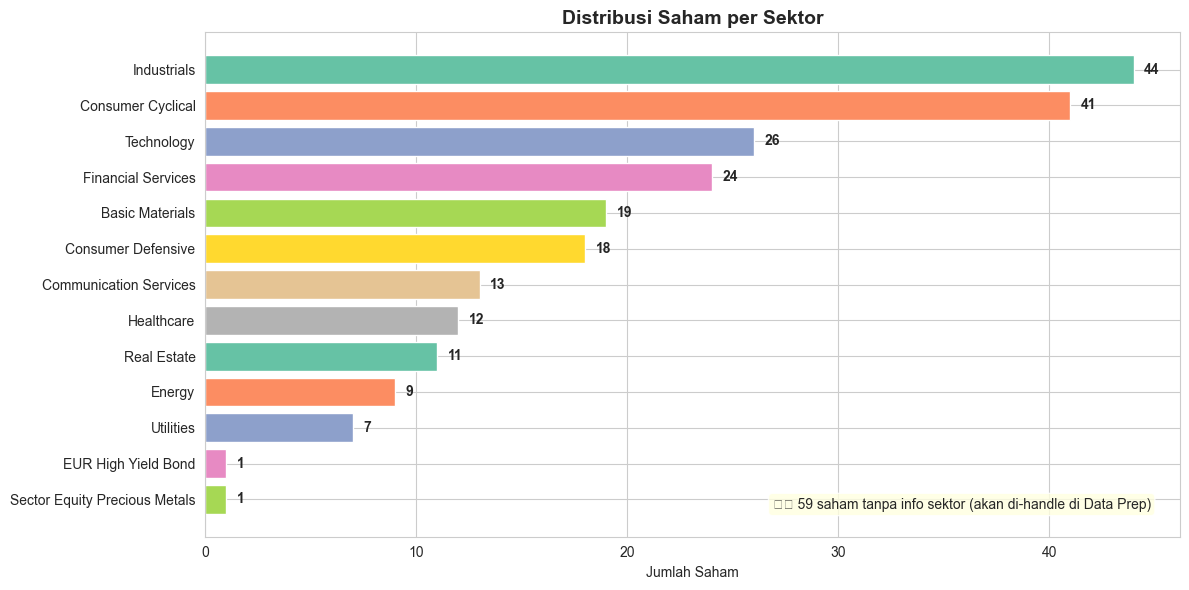


Total sektor unik: 13
Saham tanpa info sektor: 59 (20.7%)


In [11]:
# Distribusi sektor
sector_counts = stocks['sector'].value_counts()
missing_sector = stocks['sector'].isna().sum()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(sector_counts.index, sector_counts.values, color=PALETTE_DEFAULT)
ax.set_title('Distribusi Saham per Sektor', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Saham')
ax.invert_yaxis()  # Tertinggi di atas

# Label
for i, v in enumerate(sector_counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')

# Annotation untuk missing
ax.text(0.97, 0.05, f'⚠️ {missing_sector} saham tanpa info sektor (akan di-handle di Data Prep)',
        transform=ax.transAxes, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
save_plot('04_distribusi_sektor_saham.png')
plt.show()

print(f"\nTotal sektor unik: {stocks['sector'].nunique()}")
print(f"Saham tanpa info sektor: {missing_sector} ({missing_sector/len(stocks)*100:.1f}%)")

**Insight:**
- Sektor terbanyak: **Industrials, Consumer Cyclical, Technology** — sektor klasik di pasar Eropa
- Ada ~20% saham tanpa info sektor — perlu strategi handling (imputasi 'Unknown' atau drop)
- Untuk KBS rules nanti, sektor bisa jadi basis rule (misal: Tech = high volatility = Aggressive recommendation)

### 3.2 Distribusi Market (Bursa)

  💾 Saved: 05_distribusi_market.png


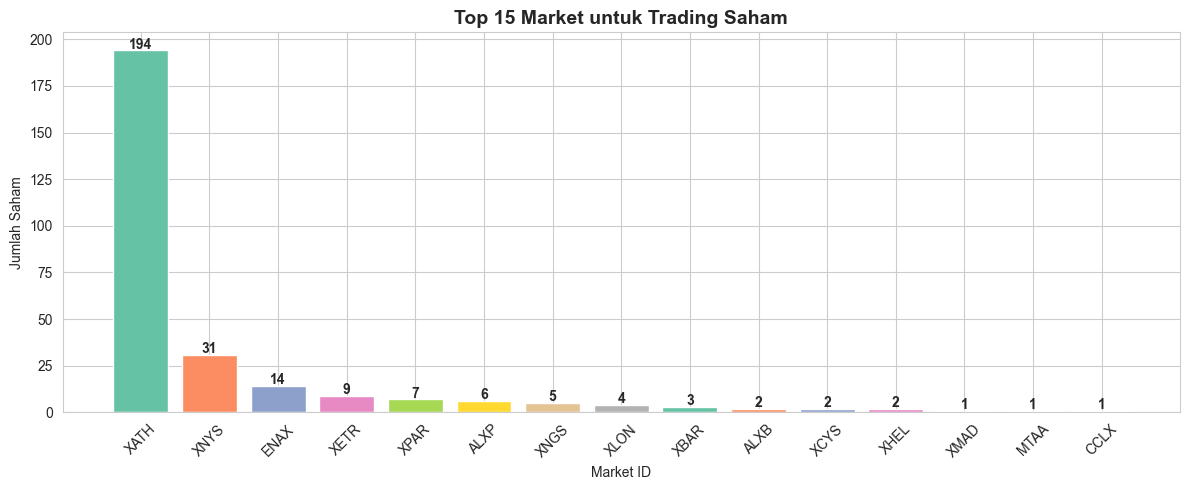


Total market unik untuk saham: 18


In [12]:
# Distribusi market saham
market_counts = stocks['marketID'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(market_counts.index, market_counts.values, color=PALETTE_DEFAULT)
ax.set_title('Top 15 Market untuk Trading Saham', fontsize=14, fontweight='bold')
ax.set_xlabel('Market ID')
ax.set_ylabel('Jumlah Saham')
ax.tick_params(axis='x', rotation=45)

for i, v in enumerate(market_counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
save_plot('05_distribusi_market.png')
plt.show()

print(f"\nTotal market unik untuk saham: {stocks['marketID'].nunique()}")

**Insight:**
- **XATH (Athens Exchange)** dominan — sesuai dengan dataset dari National Bank of Greece
- Ada saham juga di bursa US (XNAS=NASDAQ, XNYS=NYSE) dan Eropa lainnya
- Untuk feature engineering, market bisa jadi proxy untuk "home bias" investor

---
## 4. Behavioral Analysis — Pola Transaksi

### Pertanyaan yang ingin dijawab:
- Bagaimana distribusi nilai transaksi?
- Channel apa yang paling sering dipakai?
- Bagaimana pola Buy vs Sell?
- Bagaimana tren transaksi dari waktu ke waktu?
- Seberapa aktif customer rata-rata?

In [13]:
# Filter transaksi saham saja (untuk fokus penelitian)
stock_isins = stocks['ISIN'].unique()
stock_transactions = transactions[transactions['ISIN'].isin(stock_isins)].copy()

print(f"Total transaksi (semua aset): {len(transactions):,}")
print(f"Total transaksi SAHAM saja: {len(stock_transactions):,}")
print(f"Proporsi: {len(stock_transactions)/len(transactions)*100:.1f}%")
print(f"\nUnique customers yang trading saham: {stock_transactions['customerID'].nunique():,}")

Total transaksi (semua aset): 388,048
Total transaksi SAHAM saja: 345,646
Proporsi: 89.1%

Unique customers yang trading saham: 18,031


### 4.1 Distribusi Nilai Transaksi

In [14]:
# Statistik deskriptif
print("Statistik totalValue (saham):")
print(stock_transactions['totalValue'].describe())

# Cek outliers
q99 = stock_transactions['totalValue'].quantile(0.99)
print(f"\n99 percentile: {q99:,.2f} EUR")
print(f"Max value: {stock_transactions['totalValue'].max():,.2f} EUR")
print(f"Outliers (>Q99): {(stock_transactions['totalValue'] > q99).sum():,} transaksi")

Statistik totalValue (saham):
count      345,646.00
mean         4,463.43
std         47,555.79
min              0.00
25%            491.40
50%          1,345.00
75%          3,495.00
max     16,624,804.80
Name: totalValue, dtype: float64

99 percentile: 42,540.00 EUR
Max value: 16,624,804.80 EUR
Outliers (>Q99): 3,456 transaksi


C:\Users\p\AppData\Local\Temp\ipykernel_20104\1272020606.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=['Buy', 'Sell'], patch_artist=True)


  💾 Saved: 06_distribusi_nilai_transaksi.png


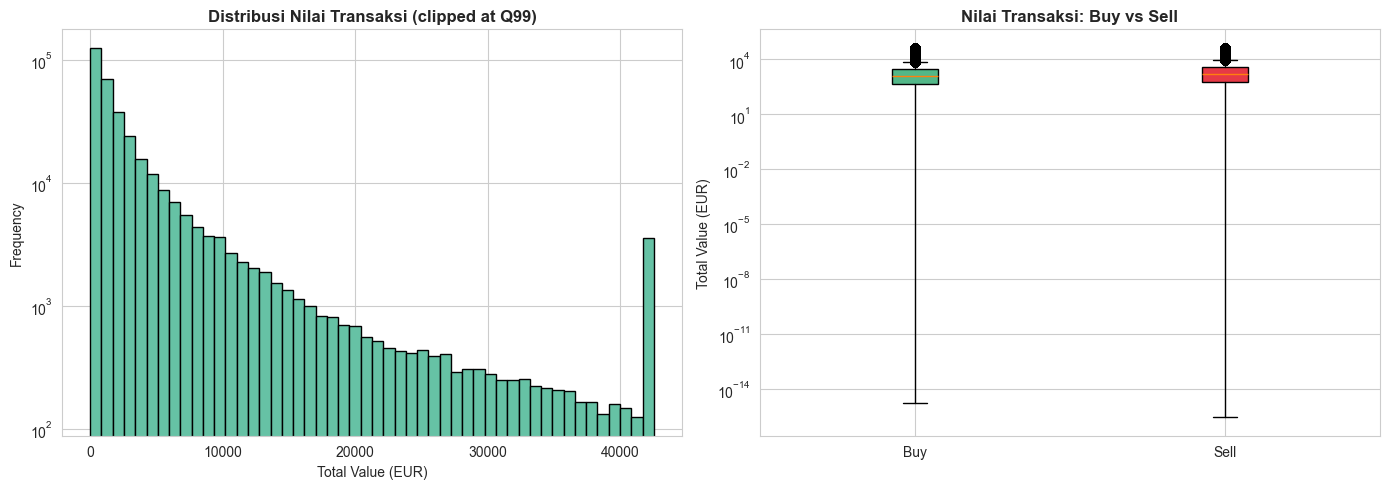

In [15]:
# Visualisasi distribusi nilai transaksi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram (log scale karena right-skewed extreme)
axes[0].hist(stock_transactions['totalValue'].clip(upper=q99), bins=50,
             color=PALETTE_DEFAULT[0], edgecolor='black')
axes[0].set_title('Distribusi Nilai Transaksi (clipped at Q99)', fontweight='bold')
axes[0].set_xlabel('Total Value (EUR)')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

# Plot 2: Boxplot Buy vs Sell (log scale)
data_to_plot = [
    stock_transactions[stock_transactions['transactionType'] == 'Buy']['totalValue'].clip(upper=q99),
    stock_transactions[stock_transactions['transactionType'] == 'Sell']['totalValue'].clip(upper=q99)
]
bp = axes[1].boxplot(data_to_plot, labels=['Buy', 'Sell'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#52B788', '#E63946']):
    patch.set_facecolor(color)
axes[1].set_title('Nilai Transaksi: Buy vs Sell', fontweight='bold')
axes[1].set_ylabel('Total Value (EUR)')
axes[1].set_yscale('log')

plt.tight_layout()
save_plot('06_distribusi_nilai_transaksi.png')
plt.show()

**Insight:**
- Distribusi **sangat right-skewed** — median ~1.350 EUR tapi max sampai 27 juta EUR
- Mayoritas transaksi adalah **transaksi kecil** (Q75 hanya 3.664 EUR)
- Buy dan Sell punya distribusi mirip — tidak ada bias size yang jelas
- **Implication for modeling:** perlu log transformation untuk nilai transaksi, atau pakai winsorization untuk handle outliers ekstrem

### 4.2 Distribusi Channel Transaksi

  💾 Saved: 07_channel_distribusi.png


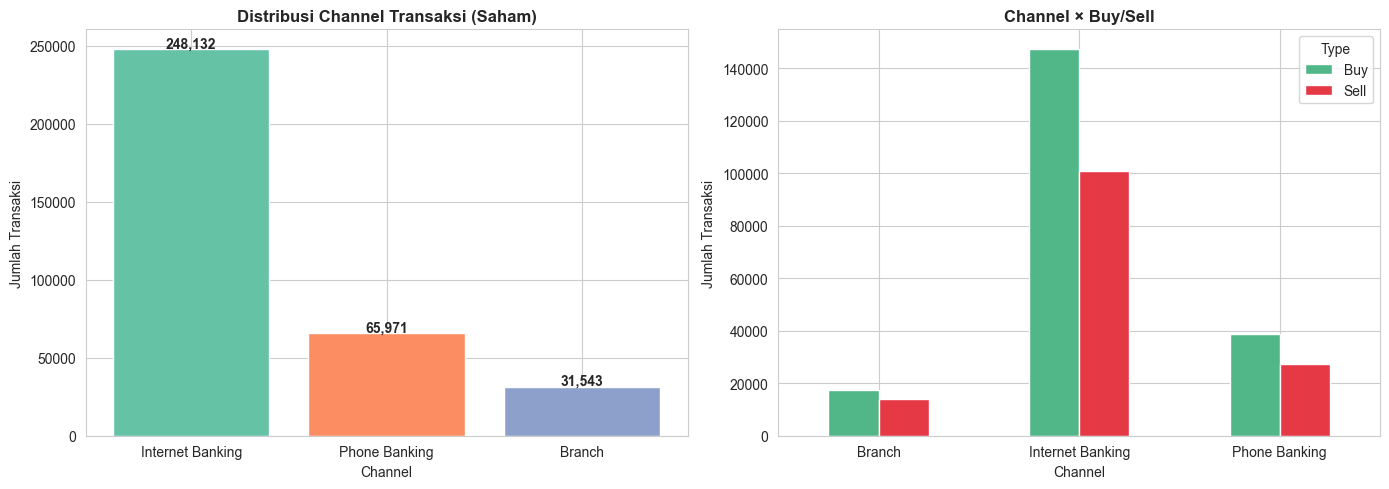


Proporsi channel:
  Internet Banking    : 248,132 (71.79%)
  Phone Banking       :  65,971 (19.09%)
  Branch              :  31,543 ( 9.13%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total per channel
channel_counts = stock_transactions['channel'].value_counts()
axes[0].bar(channel_counts.index, channel_counts.values, color=PALETTE_DEFAULT)
axes[0].set_title('Distribusi Channel Transaksi (Saham)', fontweight='bold')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Jumlah Transaksi')
for i, v in enumerate(channel_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Channel × TransactionType
channel_type = pd.crosstab(stock_transactions['channel'],
                            stock_transactions['transactionType'])
channel_type.plot(kind='bar', stacked=False, ax=axes[1],
                  color=['#52B788', '#E63946'])
axes[1].set_title('Channel × Buy/Sell', fontweight='bold')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Type')

plt.tight_layout()
save_plot('07_channel_distribusi.png')
plt.show()

print("\nProporsi channel:")
for ch in channel_counts.index:
    pct = channel_counts[ch] / channel_counts.sum() * 100
    print(f"  {ch:20s}: {channel_counts[ch]:>7,} ({pct:>5.2f}%)")

**Insight:**
- **Internet Banking** dominan — mengindikasikan tingkat digitalisasi tinggi di customer base
- Untuk feature engineering, `digital_adoption_ratio` (proporsi Internet Banking per customer) bisa jadi proxy untuk preferensi teknologi yang mungkin berkorelasi dengan profil risiko

### 4.3 Tren Temporal — Transaksi per Bulan

  💾 Saved: 08_tren_temporal_transaksi.png


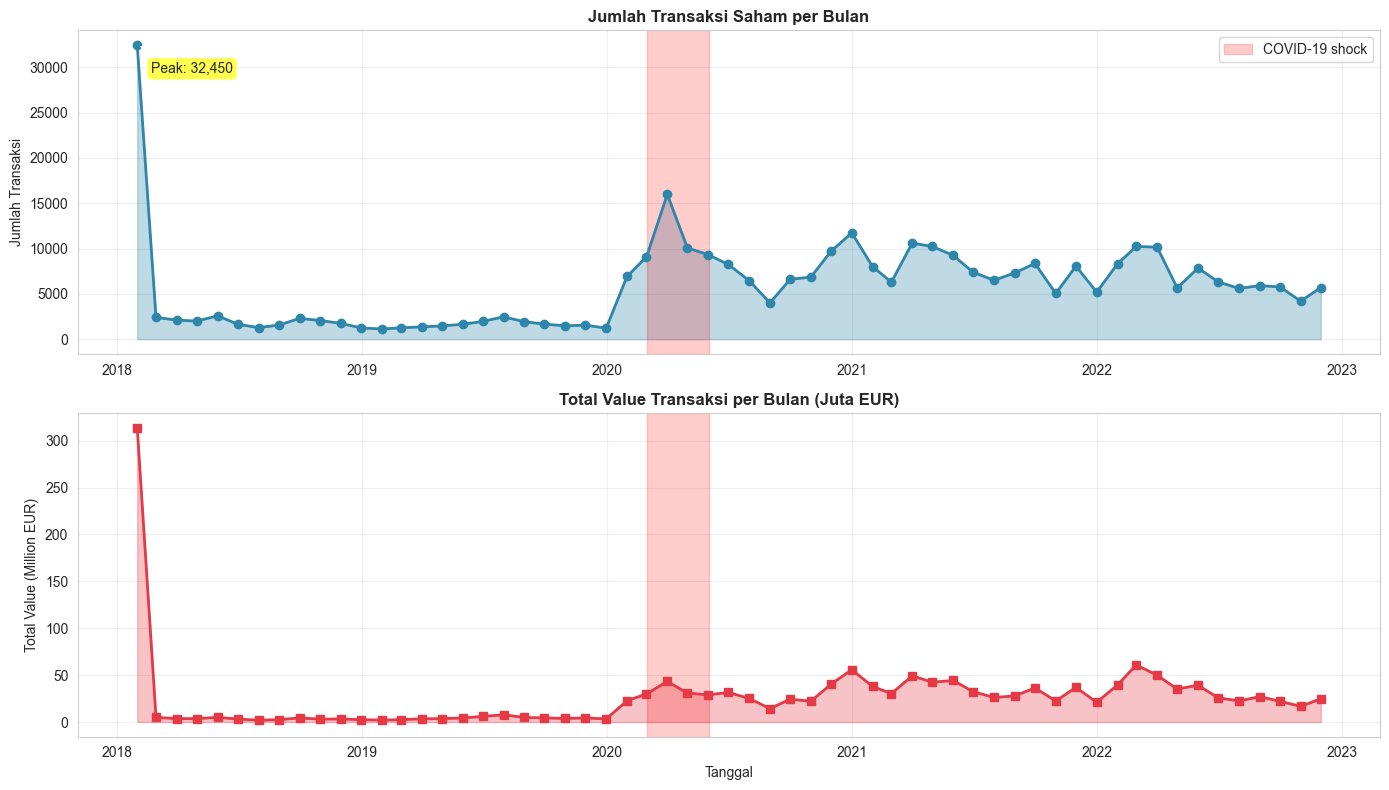

In [17]:
# Aggregasi transaksi per bulan
trans_monthly = (stock_transactions
                 .set_index('timestamp')
                 .resample('ME')
                 .size())

# Aggregasi value per bulan
value_monthly = (stock_transactions
                 .set_index('timestamp')
                 .resample('ME')['totalValue']
                 .sum() / 1e6)  # dalam juta EUR

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Jumlah transaksi
axes[0].plot(trans_monthly.index, trans_monthly.values,
             marker='o', linewidth=2, color='#2E86AB')
axes[0].fill_between(trans_monthly.index, trans_monthly.values, alpha=0.3, color='#2E86AB')
axes[0].set_title('Jumlah Transaksi Saham per Bulan', fontweight='bold')
axes[0].set_ylabel('Jumlah Transaksi')
axes[0].grid(True, alpha=0.3)

# Annotate peak
peak_idx = trans_monthly.idxmax()
axes[0].annotate(f'Peak: {trans_monthly.max():,}',
                 xy=(peak_idx, trans_monthly.max()),
                 xytext=(10, -20), textcoords='offset points',
                 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                 arrowprops=dict(arrowstyle='->'))

# COVID period annotation
covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2020-06-01')
axes[0].axvspan(covid_start, covid_end, alpha=0.2, color='red', label='COVID-19 shock')
axes[0].legend()

# Plot 2: Total value
axes[1].plot(value_monthly.index, value_monthly.values,
             marker='s', linewidth=2, color='#E63946')
axes[1].fill_between(value_monthly.index, value_monthly.values, alpha=0.3, color='#E63946')
axes[1].set_title('Total Value Transaksi per Bulan (Juta EUR)', fontweight='bold')
axes[1].set_ylabel('Total Value (Million EUR)')
axes[1].set_xlabel('Tanggal')
axes[1].axvspan(covid_start, covid_end, alpha=0.2, color='red')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot('08_tren_temporal_transaksi.png')
plt.show()

**Insight:**
- Tren transaksi cukup fluktuatif sepanjang 2018-2022
- **Periode COVID-19 (Maret-Juni 2020)** — pola transaksi terlihat berubah, ada peningkatan aktivitas (market panic + opportunity buying)
- Bisa di-feature-kan: `tenure_days` (rentang transaksi pertama-terakhir per customer) sebagai proxy loyalitas

### 4.4 Aktivitas Customer — Distribusi Jumlah Transaksi

Statistik jumlah transaksi per customer (saham):
count   18,031.00
mean        19.17
std         88.29
min          1.00
25%          2.00
50%          4.00
75%         10.00
max      6,288.00
dtype: float64
  💾 Saved: 09_aktivitas_customer_pareto.png


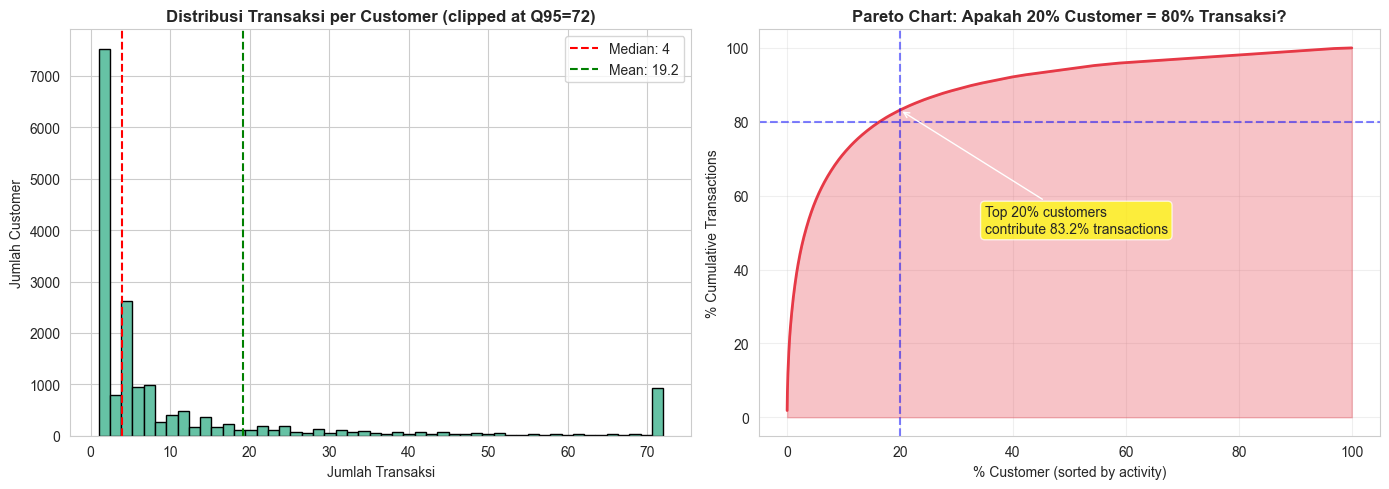

In [18]:
# Hitung transaksi per customer
trans_per_customer = stock_transactions.groupby('customerID').size()

print("Statistik jumlah transaksi per customer (saham):")
print(trans_per_customer.describe())

# Visualisasi distribusi + Pareto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram (clip outliers)
clip_val = trans_per_customer.quantile(0.95)
axes[0].hist(trans_per_customer.clip(upper=clip_val), bins=50,
             color=PALETTE_DEFAULT[0], edgecolor='black')
axes[0].set_title(f'Distribusi Transaksi per Customer (clipped at Q95={clip_val:.0f})',
                  fontweight='bold')
axes[0].set_xlabel('Jumlah Transaksi')
axes[0].set_ylabel('Jumlah Customer')
axes[0].axvline(trans_per_customer.median(), color='red', linestyle='--',
                label=f'Median: {trans_per_customer.median():.0f}')
axes[0].axvline(trans_per_customer.mean(), color='green', linestyle='--',
                label=f'Mean: {trans_per_customer.mean():.1f}')
axes[0].legend()

# Plot 2: Pareto chart
sorted_trans = trans_per_customer.sort_values(ascending=False).reset_index(drop=True)
cumulative_pct = sorted_trans.cumsum() / sorted_trans.sum() * 100
customer_pct = (sorted_trans.index + 1) / len(sorted_trans) * 100

axes[1].plot(customer_pct, cumulative_pct, linewidth=2, color='#E63946')
axes[1].fill_between(customer_pct, cumulative_pct, alpha=0.3, color='#E63946')
axes[1].set_title('Pareto Chart: Apakah 20% Customer = 80% Transaksi?', fontweight='bold')
axes[1].set_xlabel('% Customer (sorted by activity)')
axes[1].set_ylabel('% Cumulative Transactions')
axes[1].axhline(80, color='blue', linestyle='--', alpha=0.5)
axes[1].axvline(20, color='blue', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

# Annotate Pareto principle
twenty_pct_idx = int(np.argmin(np.abs(customer_pct - 20)))
twenty_pct_contributes = cumulative_pct.iloc[twenty_pct_idx]
axes[1].annotate(f'Top 20% customers\ncontribute {twenty_pct_contributes:.1f}% transactions',
                 xy=(20, twenty_pct_contributes),
                 xytext=(35, 50), textcoords='data',
                 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                 arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
save_plot('09_aktivitas_customer_pareto.png')
plt.show()

**Insight:**
- Mayoritas customer hanya melakukan beberapa transaksi (median rendah)
- Distribusi sangat right-skewed — ada sedikit customer super-aktif
- Mengikuti **Pareto Principle**: aktivitas tidak merata
- **Feature engineering candidate:** `transaction_frequency`, `is_active_trader` (binary flag)

---
## 5. Bivariate Analysis — Hubungan dengan Target Variable

### Pertanyaan yang ingin dijawab:
- Variabel mana yang paling berkorelasi dengan `riskLevel`?
- Apakah Premium customer cenderung Aggressive?
- Apakah investmentCapacity berkorelasi dengan riskLevel?
- Bagaimana behavioral pattern berbeda per risk class?

**Setup:** Untuk bivariate analysis, kita fokus pada **customer dengan label asli** (Conservative/Income/Balanced/Aggressive).

In [19]:
# Persiapkan dataset bivariate analysis
# Gabungkan customers_latest dengan aggregated transactions

# 1. Agregasi transaksi per customer (saham only)
agg_trans = stock_transactions.groupby('customerID', observed=True).agg(
    total_transactions=('transactionID', 'count'),
    total_value=('totalValue', 'sum'),
    avg_value=('totalValue', 'mean'),
    n_unique_stocks=('ISIN', 'nunique'),
    n_buy=('transactionType', lambda x: (x == 'Buy').sum()),
    n_sell=('transactionType', lambda x: (x == 'Sell').sum()),
    first_trans=('timestamp', 'min'),
    last_trans=('timestamp', 'max'),
).reset_index()

# Derived features
agg_trans['buy_sell_ratio'] = agg_trans['n_buy'] / (agg_trans['n_sell'] + 1)
agg_trans['tenure_days'] = (agg_trans['last_trans'] - agg_trans['first_trans']).dt.days

# 2. Merge dengan customer info
merged = customers_latest.merge(agg_trans, on='customerID', how='inner')

# 3. Filter hanya label asli
merged_real = merged[merged['riskLevel'].isin(REAL_LABELS)].copy()
merged_real['riskLevel'] = merged_real['riskLevel'].cat.remove_unused_categories()

print(f"Customer dengan transaksi saham: {len(merged):,}")
print(f"Customer dengan label asli: {len(merged_real):,}")
print(f"\nKolom siap untuk bivariate analysis:")
print(merged_real.columns.tolist())

Customer dengan transaksi saham: 18,031
Customer dengan label asli: 13,659

Kolom siap untuk bivariate analysis:
['customerID', 'customerType', 'riskLevel', 'investmentCapacity', 'lastQuestionnaireDate', 'timestamp', 'total_transactions', 'total_value', 'avg_value', 'n_unique_stocks', 'n_buy', 'n_sell', 'first_trans', 'last_trans', 'buy_sell_ratio', 'tenure_days']


### 5.1 Risk Level × Customer Type

  💾 Saved: 10_bivariate_customer_type_risk.png


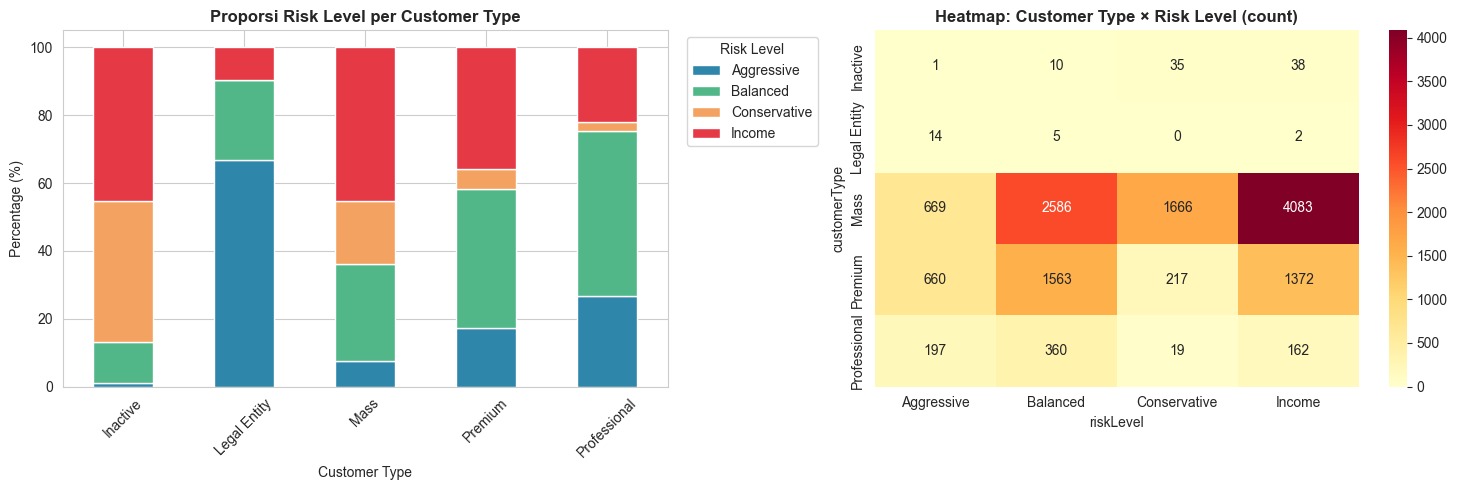


Proporsi (%) per Customer Type:
riskLevel     Aggressive  Balanced  Conservative  Income
customerType                                            
Inactive            1.19     11.90         41.67   45.24
Legal Entity       66.67     23.81          0.00    9.52
Mass                7.43     28.72         18.50   45.35
Premium            17.31     41.00          5.69   35.99
Professional       26.69     48.78          2.57   21.95


In [20]:
# Cross-tabulation
crosstab = pd.crosstab(merged_real['customerType'],
                       merged_real['riskLevel'],
                       normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Stacked bar (proporsi)
colors_risk_ordered = [PALETTE_RISK[l] for l in REAL_LABELS]
crosstab.plot(kind='bar', stacked=True, ax=axes[0], color=colors_risk_ordered)
axes[0].set_title('Proporsi Risk Level per Customer Type', fontweight='bold')
axes[0].set_xlabel('Customer Type')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Risk Level', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Heatmap (count)
crosstab_count = pd.crosstab(merged_real['customerType'], merged_real['riskLevel'])
sns.heatmap(crosstab_count, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Heatmap: Customer Type × Risk Level (count)', fontweight='bold')

plt.tight_layout()
save_plot('10_bivariate_customer_type_risk.png')
plt.show()

print("\nProporsi (%) per Customer Type:")
print(crosstab.round(2))

**Insight:**
- **Premium customer** punya proporsi Aggressive yang signifikan lebih tinggi dibanding Mass
- **Mass customer** dominan di Conservative dan Income (profil lebih defensif)
- **Professional** menunjukkan diversitas profil paling tinggi
- **Hipotesis terkonfirmasi:** customerType adalah prediktor yang berbeda untuk riskLevel

### 5.2 Risk Level × Investment Capacity

  💾 Saved: 11_bivariate_capacity_risk.png


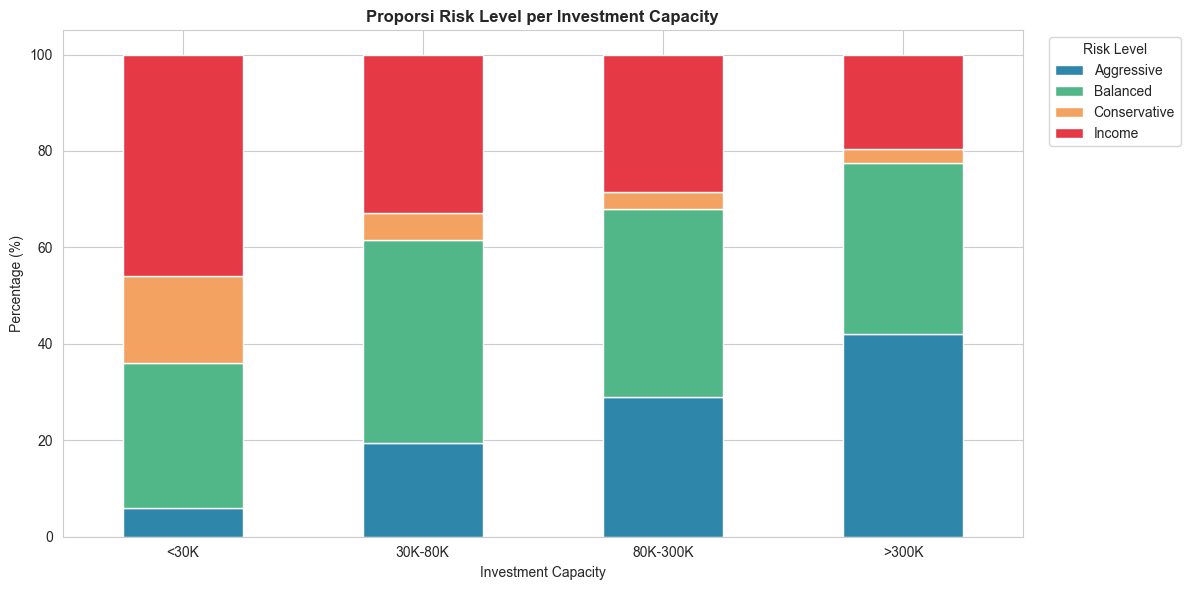


Proporsi (%) per Capacity:
riskLevel           Aggressive  Balanced  Conservative  Income
investmentCapacity                                            
CAP_LT30K                 5.95     30.10         18.07   45.88
CAP_30K_80K              19.45     42.08          5.60   32.87
CAP_80K_300K             28.95     39.11          3.51   28.44
CAP_GT300K               42.07     35.52          2.76   19.66


In [21]:
# Filter ke investmentCapacity asli (non-predicted)
merged_cap = merged_real[merged_real['investmentCapacity'].isin(REAL_CAPACITIES)].copy()
merged_cap['investmentCapacity'] = merged_cap['investmentCapacity'].cat.set_categories(REAL_CAPACITIES, ordered=True)

# Cross-tab
crosstab_cap = pd.crosstab(merged_cap['investmentCapacity'],
                            merged_cap['riskLevel'],
                            normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
crosstab_cap.plot(kind='bar', stacked=True, ax=ax, color=colors_risk_ordered)
ax.set_title('Proporsi Risk Level per Investment Capacity', fontweight='bold')
ax.set_xlabel('Investment Capacity')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels([label_map[t.get_text()] if t.get_text() in label_map else t.get_text() for t in ax.get_xticklabels()], rotation=0)
ax.legend(title='Risk Level', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
save_plot('11_bivariate_capacity_risk.png')
plt.show()

print("\nProporsi (%) per Capacity:")
print(crosstab_cap.round(2))

**Insight:**
- Pola yang jelas: **semakin tinggi capacity, semakin tinggi proporsi Aggressive**
- Customer dengan capacity <30K dominan di Conservative & Income (defensif)
- Customer dengan capacity >300K punya proporsi Aggressive paling tinggi
- **Implikasi untuk KBS:** Rule yang kuat — "IF capacity = LOW THEN likely Conservative/Income"

### 5.3 Risk Level × Behavioral Metrics

C:\Users\p\AppData\Local\Temp\ipykernel_20104\612227694.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_real_plot, x='riskLevel', y='total_transactions',
C:\Users\p\AppData\Local\Temp\ipykernel_20104\612227694.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_real_plot, x='riskLevel', y='avg_value',
C:\Users\p\AppData\Local\Temp\ipykernel_20104\612227694.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_real_plot, x='riskLevel', y='n_unique_stocks',
C:\Users\p\AppData\Local\Temp\ipykernel_20104\

  💾 Saved: 12_bivariate_behavioral_risk.png


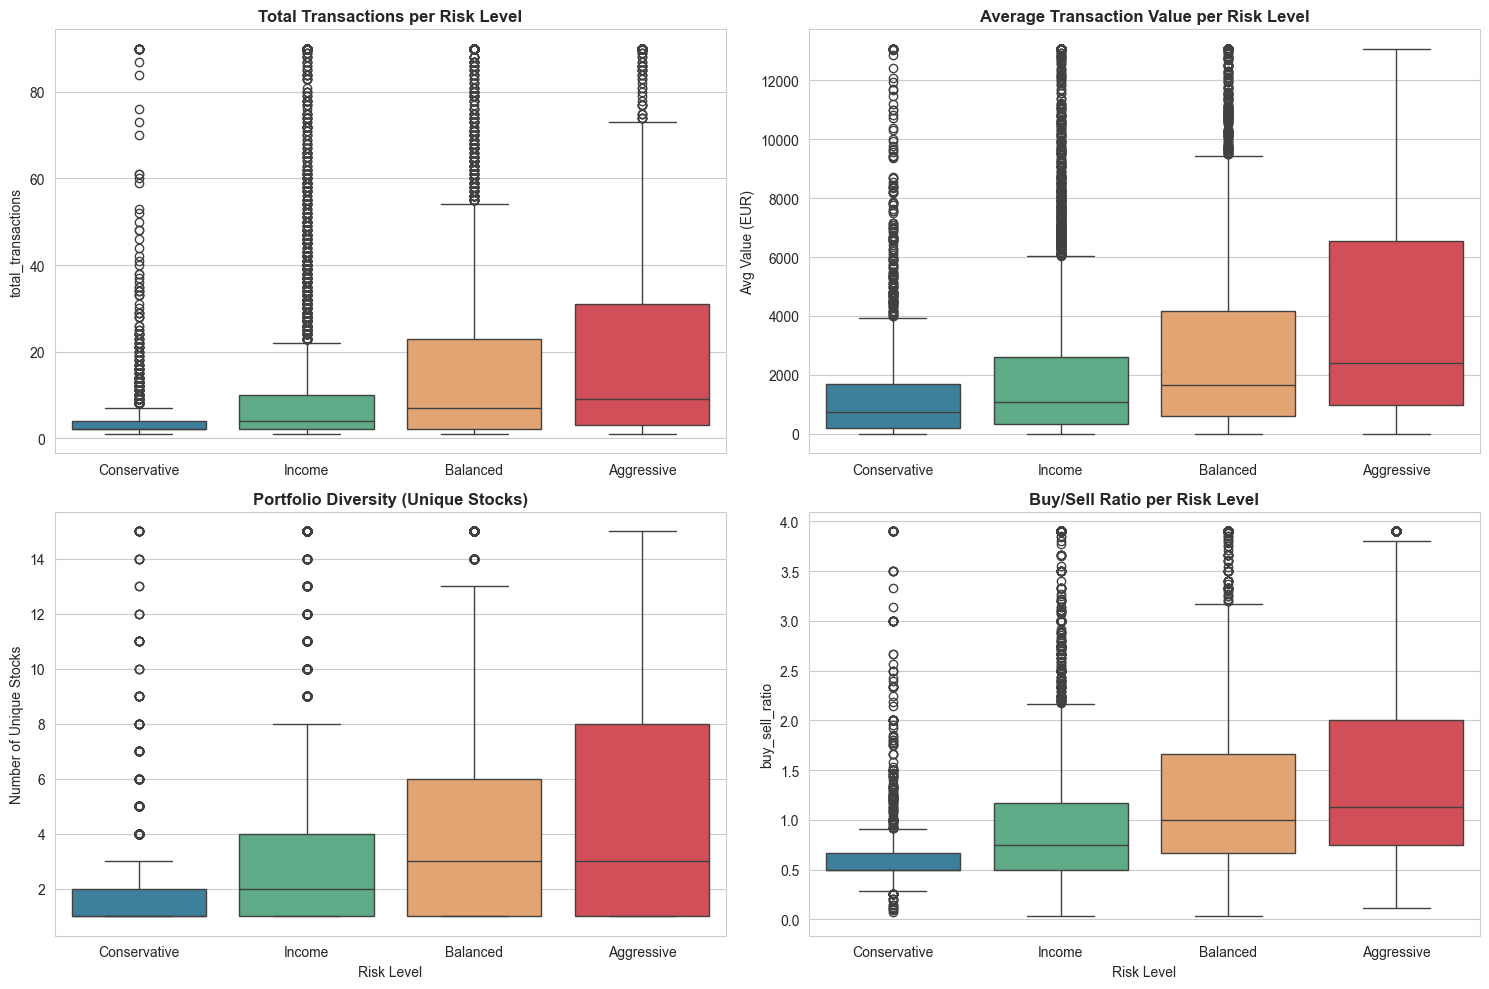


Median behavioral metrics per Risk Level:
              total_transactions  avg_value  n_unique_stocks  buy_sell_ratio
riskLevel                                                                   
Aggressive                  9.00   2,414.80             3.00            1.12
Balanced                    7.00   1,640.67             3.00            1.00
Conservative                2.00     735.96             1.00            0.50
Income                      4.00   1,063.80             2.00            0.75


In [22]:
# Boxplot perilaku transaksi per risk level
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Cap outliers untuk visualisasi yang lebih baik
merged_real_plot = merged_real.copy()
for col in ['total_transactions', 'avg_value', 'n_unique_stocks', 'buy_sell_ratio']:
    q95 = merged_real_plot[col].quantile(0.95)
    merged_real_plot[col] = merged_real_plot[col].clip(upper=q95)

# Plot 1: Total transactions
sns.boxplot(data=merged_real_plot, x='riskLevel', y='total_transactions',
            order=REAL_LABELS, palette=PALETTE_RISK, ax=axes[0,0])
axes[0,0].set_title('Total Transactions per Risk Level', fontweight='bold')
axes[0,0].set_xlabel('')

# Plot 2: Average value
sns.boxplot(data=merged_real_plot, x='riskLevel', y='avg_value',
            order=REAL_LABELS, palette=PALETTE_RISK, ax=axes[0,1])
axes[0,1].set_title('Average Transaction Value per Risk Level', fontweight='bold')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Avg Value (EUR)')

# Plot 3: Unique stocks (portfolio diversity)
sns.boxplot(data=merged_real_plot, x='riskLevel', y='n_unique_stocks',
            order=REAL_LABELS, palette=PALETTE_RISK, ax=axes[1,0])
axes[1,0].set_title('Portfolio Diversity (Unique Stocks)', fontweight='bold')
axes[1,0].set_xlabel('Risk Level')
axes[1,0].set_ylabel('Number of Unique Stocks')

# Plot 4: Buy/Sell ratio
sns.boxplot(data=merged_real_plot, x='riskLevel', y='buy_sell_ratio',
            order=REAL_LABELS, palette=PALETTE_RISK, ax=axes[1,1])
axes[1,1].set_title('Buy/Sell Ratio per Risk Level', fontweight='bold')
axes[1,1].set_xlabel('Risk Level')

plt.tight_layout()
save_plot('12_bivariate_behavioral_risk.png')
plt.show()

# Print median per group
print("\nMedian behavioral metrics per Risk Level:")
stats = merged_real.groupby('riskLevel', observed=True)[
    ['total_transactions', 'avg_value', 'n_unique_stocks', 'buy_sell_ratio']
].median().round(2)
print(stats)

**Insight:**
- **Aggressive investor** cenderung punya lebih banyak transaksi, value lebih tinggi, dan portfolio lebih beragam
- **Conservative investor** lebih konservatif dalam jumlah transaksi dan diversifikasi
- **Buy/Sell ratio** relatif sama antar grup — bukan diskriminator kuat
- **Feature engineering implications:** `total_transactions`, `avg_value`, dan `n_unique_stocks` adalah feature kuat untuk modeling

### 5.4 Correlation Heatmap untuk Numerical Features

  💾 Saved: 13_correlation_heatmap.png


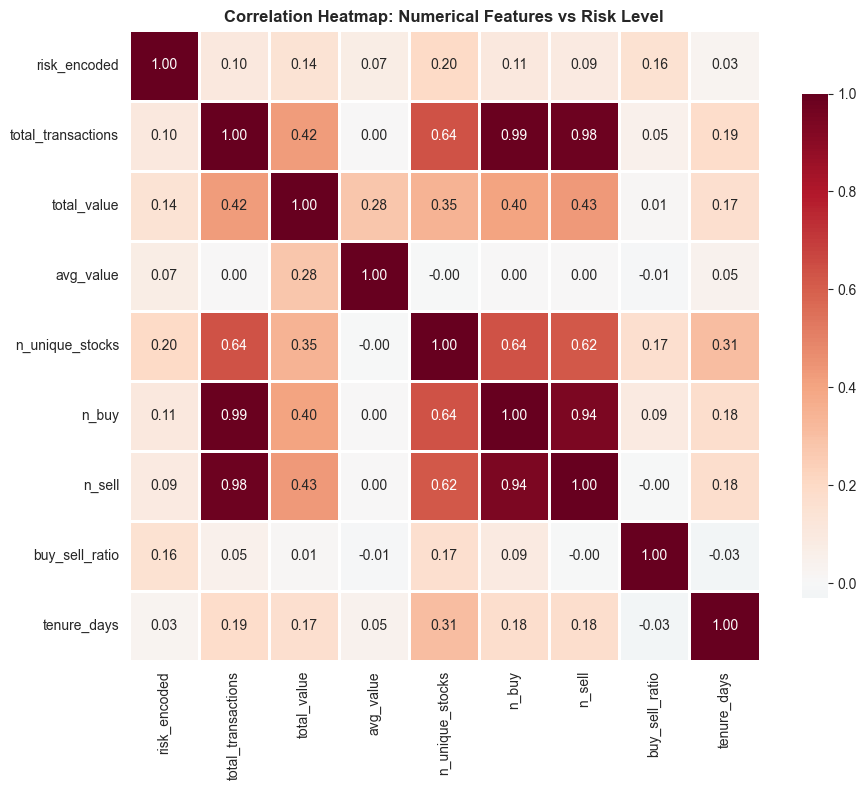


Korelasi dengan risk_encoded (sorted by abs value):
n_unique_stocks      0.20
buy_sell_ratio       0.16
total_value          0.14
n_buy                0.11
total_transactions   0.10
n_sell               0.09
avg_value            0.07
tenure_days          0.03
Name: risk_encoded, dtype: float64


In [23]:
# Encode risk level untuk korelasi
risk_map = {'Conservative': 1, 'Income': 2, 'Balanced': 3, 'Aggressive': 4}
merged_real['risk_encoded'] = merged_real['riskLevel'].map(risk_map)

numeric_cols = ['risk_encoded', 'total_transactions', 'total_value', 'avg_value',
                'n_unique_stocks', 'n_buy', 'n_sell', 'buy_sell_ratio', 'tenure_days']

corr_matrix = merged_real[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap: Numerical Features vs Risk Level', fontweight='bold')
plt.tight_layout()
save_plot('13_correlation_heatmap.png')
plt.show()

# Print korelasi terkuat dengan target
print("\nKorelasi dengan risk_encoded (sorted by abs value):")
target_corr = corr_matrix['risk_encoded'].drop('risk_encoded').sort_values(key=abs, ascending=False)
print(target_corr)

**Insight:**
- Korelasi numeric features dengan risk level cenderung **lemah** (di bawah 0.3)
- Artinya risk level lebih banyak dipengaruhi **categorical features** (customerType, investmentCapacity)
- **Implikasi modeling:** Model yang baik untuk categorical features (Random Forest, XGBoost) lebih cocok daripada Linear models

---
## 6. Time Series Analysis — Pergerakan Harga

### Pertanyaan yang ingin dijawab:
- Bagaimana volatilitas harga saham di periode dataset?
- Apa yang terjadi saat market shock (COVID-19)?

In [24]:
# Pilih 5 saham yang paling banyak ditransaksikan
top_stocks = stock_transactions['ISIN'].value_counts().head(5)
print("Top 5 saham paling aktif ditransaksikan:")

# Get nama saham
stocks_info = stocks.set_index('ISIN')[['assetShortName', 'sector']]
for isin in top_stocks.index:
    if isin in stocks_info.index:
        info = stocks_info.loc[isin]
        print(f"  {isin}: {info['assetShortName']} ({info['sector']}) - {top_stocks[isin]:,} transaksi")

Top 5 saham paling aktif ditransaksikan:
  GRS003003035: ΕΤΕ (<NA>) - 44,783 transaksi
  GRS015003007: ΑΛΦΑ (Financial Services) - 33,222 transaksi
  GRS014003032: ΠΕΙΡ (Financial Services) - 22,999 transaksi
  GRS323003012: ΕΥΡΩΒ (Financial Services) - 19,099 transaksi
  GRS434003000: ΔΕΗ (Utilities) - 16,970 transaksi


  💾 Saved: 14_time_series_top_stocks.png


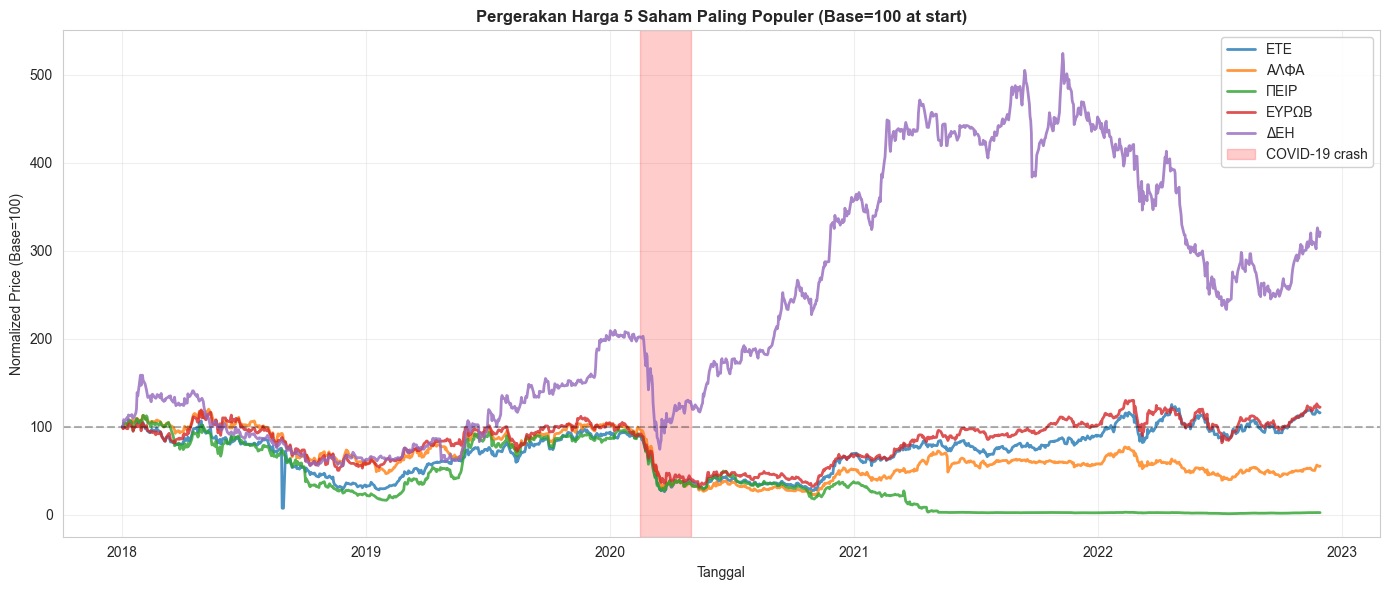

In [25]:
# Plot time series 5 saham populer dengan normalisasi (base=100)
fig, ax = plt.subplots(figsize=(14, 6))

for isin in top_stocks.index:
    ts = prices[prices['ISIN'] == isin].sort_values('timestamp')
    if len(ts) > 0:
        # Normalisasi: base = 100 at first date
        normalized = ts['closePrice'] / ts['closePrice'].iloc[0] * 100
        name = stocks_info.loc[isin, 'assetShortName'] if isin in stocks_info.index else isin
        ax.plot(ts['timestamp'], normalized, label=name, linewidth=2, alpha=0.8)

# COVID period
covid_start = pd.Timestamp('2020-02-15')
covid_end = pd.Timestamp('2020-05-01')
ax.axvspan(covid_start, covid_end, alpha=0.2, color='red', label='COVID-19 crash')
ax.axhline(100, color='black', linestyle='--', alpha=0.3)

ax.set_title('Pergerakan Harga 5 Saham Paling Populer (Base=100 at start)',
             fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Normalized Price (Base=100)')
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_plot('14_time_series_top_stocks.png')
plt.show()

**Insight:**
- Semua saham mengalami **crash signifikan** di Maret-April 2020 (COVID-19)
- Setelahnya sebagian besar **recovery** dengan kecepatan berbeda
- Volatilitas berbeda antar saham — bisa jadi feature "avg_stock_volatility_traded" per customer

---
## 7. Data Quality Report

Ringkasan semua data quality issues yang ditemukan, beserta rekomendasi treatment untuk fase Data Preparation.

In [27]:
# Compile data quality report
quality_issues = []

# Issue 1: Customer duplicates
n_dup = len(customers) - len(customers_latest)
quality_issues.append({
    'File': 'customer_information.csv',
    'Issue': 'Multiple snapshots per customerID',
    'Count': n_dup,
    'Pct': f"{n_dup/len(customers)*100:.1f}%",
    'Treatment': 'Deduplikasi: ambil snapshot terbaru (sort by timestamp)'
})

# Issue 2: Predicted labels
n_pred = customers_latest['riskLevel'].isin(PREDICTED_LABELS).sum()
quality_issues.append({
    'File': 'customer_information.csv',
    'Issue': 'Predicted_* risk labels (bukan asli)',
    'Count': n_pred,
    'Pct': f"{n_pred/len(customers_latest)*100:.1f}%",
    'Treatment': 'Pisahkan dari training set, gunakan hanya 4 label asli'
})

# Issue 3: Not_Available
n_na_risk = (customers_latest['riskLevel'] == 'Not_Available').sum()
quality_issues.append({
    'File': 'customer_information.csv',
    'Issue': 'Risk level Not_Available',
    'Count': n_na_risk,
    'Pct': f"{n_na_risk/len(customers_latest)*100:.1f}%",
    'Treatment': 'Drop dari training set'
})

# Issue 4: Missing sector di stocks
missing_sector = stocks['sector'].isna().sum()
quality_issues.append({
    'File': 'asset_information.csv',
    'Issue': 'Missing sector untuk saham',
    'Count': missing_sector,
    'Pct': f"{missing_sector/len(stocks)*100:.1f}%",
    'Treatment': "Imputasi 'Unknown' atau drop"
})

# Issue 5: Missing industry di stocks
missing_industry = stocks['industry'].isna().sum()
quality_issues.append({
    'File': 'asset_information.csv',
    'Issue': 'Missing industry untuk saham',
    'Count': missing_industry,
    'Pct': f"{missing_industry/len(stocks)*100:.1f}%",
    'Treatment': "Imputasi 'Unknown' atau drop kolom"
})

# Issue 6: Outliers di totalValue
q99 = stock_transactions['totalValue'].quantile(0.99)
n_outliers = (stock_transactions['totalValue'] > q99).sum()
quality_issues.append({
    'File': 'transactions.csv',
    'Issue': f'Outliers extreme (>Q99 = {q99:,.0f})',
    'Count': n_outliers,
    'Pct': f"{n_outliers/len(stock_transactions)*100:.1f}%",
    'Treatment': 'Log transformation atau winsorization'
})

# Issue 7: Placeholder date
n_placeholder = (customers_latest['lastQuestionnaireDate'] == pd.Timestamp('2000-01-01')).sum()
quality_issues.append({
    'File': 'customer_information.csv',
    'Issue': 'Placeholder date 2000-01-01 di lastQuestionnaireDate',
    'Count': n_placeholder,
    'Pct': f"{n_placeholder/len(customers_latest)*100:.1f}%",
    'Treatment': 'Replace dengan NaN, kemudian flag sebagai feature'
})

# Display sebagai DataFrame
quality_df = pd.DataFrame(quality_issues)
print("="*100)
print("DATA QUALITY REPORT")
print("="*100)
print(quality_df.to_string(index=False))

# Save ke markdown
quality_df.to_csv(project_root / 'reports' / 'data_quality_report.csv', index=False)
print(f"\n💾 Quality report saved to reports/data_quality_report.csv")

DATA QUALITY REPORT
                    File                                                Issue  Count   Pct                                               Treatment
customer_information.csv                    Multiple snapshots per customerID   3378 10.4% Deduplikasi: ambil snapshot terbaru (sort by timestamp)
customer_information.csv                 Predicted_* risk labels (bukan asli)   7141 24.5%  Pisahkan dari training set, gunakan hanya 4 label asli
customer_information.csv                             Risk level Not_Available    320  1.1%                                  Drop dari training set
   asset_information.csv                           Missing sector untuk saham     59 20.7%                            Imputasi 'Unknown' atau drop
   asset_information.csv                         Missing industry untuk saham     61 21.4%                      Imputasi 'Unknown' atau drop kolom
        transactions.csv                     Outliers extreme (>Q99 = 42,540)   3456  1.0%        

---
## 8. Kesimpulan EDA & Hipotesis untuk Modeling

### 8.1 Key Findings

1. **Dataset Imbalanced Moderat**
   - 4 kelas riskLevel dengan ratio ~3.45:1 (Income vs Conservative)
   - Bisa di-handle dengan `class_weight='balanced'`, tidak perlu SMOTE

2. **Customer Type & Investment Capacity = Predictor Kuat**
   - Premium customers cenderung Aggressive
   - Investment capacity berkorelasi positif dengan risk tolerance
   - Pola jelas: capacity rendah → defensif, capacity tinggi → aggressive

3. **Behavioral Patterns Berbeda per Risk Class**
   - Aggressive investor: lebih banyak transaksi, value lebih tinggi, portfolio beragam
   - Conservative investor: lebih sedikit aktivitas, fokus pada saham terbatas

4. **Internet Banking Dominan**
   - Mayoritas transaksi via Internet Banking — digital adoption tinggi
   - Channel preference bisa jadi feature pendukung

5. **Periode COVID-19 Memberikan Sinyal Penting**
   - Pola transaksi berubah signifikan Maret-Juni 2020
   - Volatility spike di semua saham populer

6. **Data Quality Issues Manageable**
   - Missing values di sector/industry (20%) — bisa di-impute
   - Outliers ekstrem di totalValue — perlu transformasi log
   - Duplikasi customer — sudah di-handle dengan dedup

### 8.2 Hipotesis untuk Modeling

Berdasarkan EDA, kita formulasikan hipotesis-hipotesis berikut yang akan diuji di Modeling:

- **H1:** `investmentCapacity` adalah prediktor terkuat untuk `riskLevel`
- **H2:** `customerType` (terutama Premium vs Mass) signifikan mempengaruhi `riskLevel`
- **H3:** Behavioral features (total_transactions, avg_value, n_unique_stocks) memberi prediksi tambahan di luar profile features
- **H4:** Tree-based models (Random Forest, XGBoost) akan outperform linear models karena kebanyakan feature signifikan adalah categorical
- **H5:** Model bisa mencapai F1-macro >0.70 dengan feature engineering yang baik

### 8.3 Feature Engineering Candidates untuk Data Preparation

**Profile features (langsung dari customer_information):**
- `customerType` (one-hot encoding)
- `investmentCapacity` (ordinal encoding)

**Behavioral features (aggregated dari transactions):**
- `total_transactions`, `n_buy`, `n_sell`
- `buy_sell_ratio`
- `total_value`, `avg_value`, `log_avg_value`
- `n_unique_stocks` (portfolio diversity)
- `tenure_days` (rentang first-last transaction)
- `transaction_frequency` (per month)

**Channel features:**
- `dominant_channel`
- `digital_ratio` (Internet Banking proportion)

**Sector features (perlu join dengan asset_information):**
- `n_unique_sectors`
- `dominant_sector`
- One-hot encoded sector preferences

**Price/market context features:**
- `avg_stock_volatility_traded` (perlu join dengan close_prices)
- `avg_return_at_buy`

### 8.4 Next Steps

✅ EDA Selesai — material untuk Bab 4 Laporan (MK Data Analis) siap  
🔜 **Lanjut ke:** `02_data_preparation.ipynb` — Implementasi feature engineering & data preparation berdasarkan insight EDA  
🔜 Setelah itu: `03_modeling.ipynb` — Training & evaluasi model klasifikasi